In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score
)


In [8]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
RANDOM_STATE=42

In [9]:
fraud=pd.read_csv("/content/creditcard.csv")

In [10]:
fraud.shape

(19898, 31)

In [11]:
fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0.000
1,0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0.000
2,1,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0.000
3,1,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0.000
4,2,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0.000


Class :

0-> Non Fraud

1-> Fraud

In [12]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19898 entries, 0 to 19897
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    19898 non-null  int64  
 1   V1      19898 non-null  float64
 2   V2      19898 non-null  float64
 3   V3      19898 non-null  float64
 4   V4      19898 non-null  float64
 5   V5      19898 non-null  float64
 6   V6      19898 non-null  float64
 7   V7      19898 non-null  float64
 8   V8      19898 non-null  float64
 9   V9      19898 non-null  float64
 10  V10     19898 non-null  float64
 11  V11     19897 non-null  float64
 12  V12     19897 non-null  float64
 13  V13     19897 non-null  float64
 14  V14     19897 non-null  float64
 15  V15     19897 non-null  float64
 16  V16     19897 non-null  float64
 17  V17     19897 non-null  float64
 18  V18     19897 non-null  float64
 19  V19     19897 non-null  float64
 20  V20     19897 non-null  float64
 21  V21     19897 non-null  float64
 22

In [13]:
fraud.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [14]:
for col in fraud.columns:
    print(fraud[col].value_counts().head())

Time
3767     21
3770     20
19912    19
3750     19
3760     17
Name: count, dtype: int64
V1
-0.303    36
0.899     28
1.013     24
1.284     23
1.110     19
Name: count, dtype: int64
V2
0.447     36
0.034     28
0.185     24
-0.529    23
0.368     19
Name: count, dtype: int64
V3
-0.496    36
-0.083    28
1.857     24
-0.552    23
-0.061    19
Name: count, dtype: int64
V4
-3.215    36
1.256     28
2.626     24
-1.692    23
1.377     19
Name: count, dtype: int64
V5
2.705     36
0.554     28
-0.814    24
1.390     23
0.070     19
Name: count, dtype: int64
V6
2.762     36
0.702     28
0.741     24
3.487     23
-1.101    19
Name: count, dtype: int64
V7
0.594     36
0.156     28
-1.051    24
-1.223    23
0.610     19
Name: count, dtype: int64
V8
0.556     36
0.196     28
0.411     24
0.876     23
-0.487    19
Name: count, dtype: int64
V9
0.698    36
1.161    28
1.078    24
2.955    23
0.921    19
Name: count, dtype: int64
V10
-1.090    36
-0.518    28
0.411     24
-1.399    23
-0.381    19

In [15]:
duplicate_mask=fraud.duplicated()
num_duplicates=duplicate_mask.sum()
print("Number of duplicate rows:",num_duplicates)

Number of duplicate rows: 69


Target Distribution

In [16]:
fraud["Class"].value_counts(normalize=True)*100

,proportion
Class,
0.000,99.573
1.000,0.427


In [17]:
non_fraud=(fraud['Class']==0).sum()
net_fraud=(fraud['Class']==1).sum()
try:
    ratio=round((non_fraud)/max(net_fraud,1),2)
except ZeroDivisonError:
    pass

print("\n Indicating ratio (Non_fraud :fraud)=",ratio)


 Indicating ratio (Non_fraud :fraud)= 233.08


In [18]:
fraud[['Time',"Amount"]].describe()

,Time,Amount
count,19898.000,19897.000
mean,15492.416,70.271
std,10512.067,205.364
min,0.000,0.000
25%,4536.250,5.750
50%,14796.000,16.000
75%,26220.500,59.980
max,30633.000,7879.420


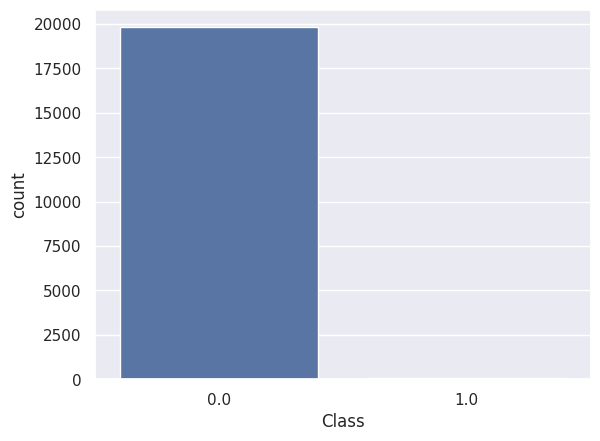

In [19]:
sns.countplot(x="Class",data=fraud)
plt.show()

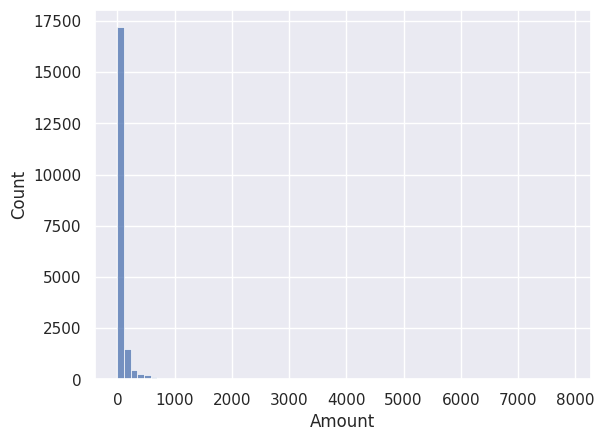

In [20]:
sns.histplot(fraud["Amount"],bins=68)
plt.show()

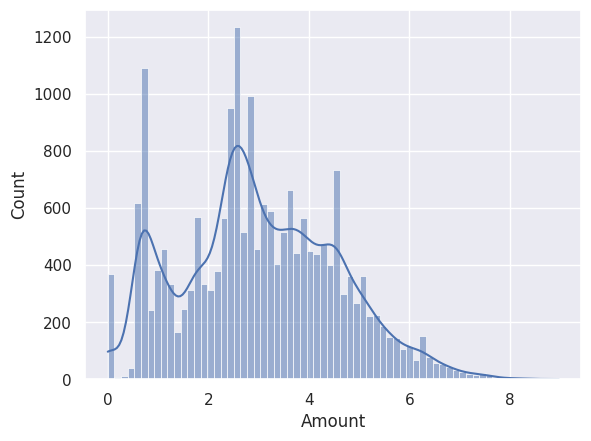

In [21]:
sns.histplot(np.log1p(fraud["Amount"]),bins=68,kde=True)
plt.show()

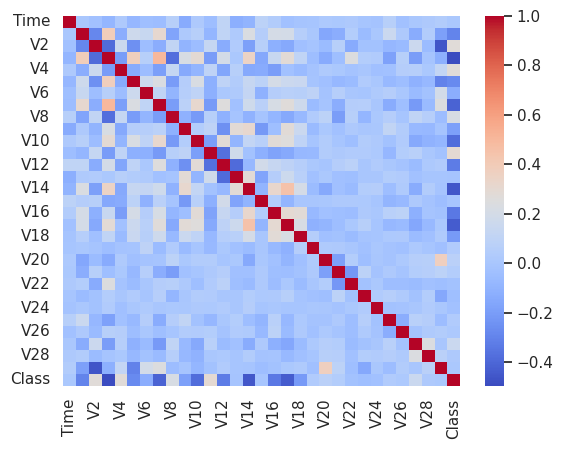

In [22]:
sns.heatmap(fraud.corr(),cmap="coolwarm")
plt.show()

In [23]:
corr_target=fraud.corr(numeric_only=True)['Class'].sort_values(ascending=True)
corr_target.head(),corr_target.tail()

(V3    -0.495
 V14   -0.458
 V17   -0.439
 V7    -0.414
 V10   -0.379
 Name: Class, dtype: float64,
 V8      0.219
 V4      0.271
 V2      0.271
 V11     0.296
 Class   1.000
 Name: Class, dtype: float64)

In [24]:
fraud['Amount_log1P']=np.log1p(fraud['Amount'])

In [25]:
fraud.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log1P
0,0,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0.000,5.015
1,0,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0.000,1.306


In [35]:
x=fraud.drop(columns=['Class','Amount'])
y=fraud['Class']

In [34]:
fraud.dropna(inplace=True)

In [36]:
X_train,X_test,y_train,y_test=train_test_split(x,y,stratify=y,test_size=0.2,random_state=RANDOM_STATE)

#### Base Line model

In [37]:
base_pipeline=Pipeline(
    [
        ("model",DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [38]:
base_pipeline.fit(X_train,y_train)

Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])

In [39]:
y_base_train_pred=base_pipeline.predict(X_train)
y_base_test_pred=base_pipeline.predict(X_test)


In [40]:
base_train_accr=accuracy_score(y_train,y_base_train_pred)*100
base_test_accr=accuracy_score(y_test,y_base_test_pred)*100
y=round(base_train_accr,2)
print("Baseline Train Accuracy:",round(base_train_accr,2))
print("Baseline Test Accuracy:",round(base_test_accr,2))



Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.8


In [41]:
print("Classification Report",classification_report(y_test,y_base_test_pred))

Classification Report               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3963
         1.0       0.80      0.71      0.75        17

    accuracy                           1.00      3980
   macro avg       0.90      0.85      0.87      3980
weighted avg       1.00      1.00      1.00      3980



In [42]:
y_test_prob=base_pipeline.predict_proba(X_test)[:,1]
print("Test Average precison Score:",average_precision_score(y_test,y_test_prob))

Test Average precison Score: 0.5659621637599764


Model optimization

In [45]:
K=5
cv=StratifiedKFold(n_splits=K,shuffle=True,random_state=RANDOM_STATE)

In [43]:
models={
    "dt_balanced":Pipeline(
        [
            ("model",DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"


                ))
        ]
    ),
    "hgb_balanced":Pipeline(
        [
            ("model",HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"

                ))
        ]
    ),
    "rf_balanced":Pipeline(
        [
            ('model',RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
                ))
        ]
    )
}

In [46]:
for name,m in models.items():
    pr_auc_score=[]

    for tr_idx,te_idx in cv.split(X_train,y_train):

        X_tr, X_te=X_train.iloc[tr_idx],X_train.iloc[te_idx]
        y_tr, y_te=y_train.iloc[tr_idx],y_train.iloc[te_idx]

        m.fit(X_tr,y_tr)
        pred_prob=m.predict_proba(X_te)[:,1]

        pr_auc_score.append(average_precision_score(y_te,pred_prob))



    print("Model Name: ", name)
    print("Pr auc socre: ",pr_auc_score)
    print("CV Pr auc score:",round(float(np.mean(pr_auc_score)),4))

Model Name:  dt_balanced
Pr auc socre:  [np.float64(0.6506069307576845), np.float64(0.8625589683109425), np.float64(0.7915229602317255), np.float64(0.6654635028810335), np.float64(0.7155423903774517)]
CV Pr auc score: 0.7371
Model Name:  hgb_balanced
Pr auc socre:  [np.float64(0.8494404846959027), np.float64(1.0), np.float64(0.916331707508178), np.float64(0.865615577030725), np.float64(0.730013089503295)]
CV Pr auc score: 0.8723
Model Name:  rf_balanced
Pr auc socre:  [np.float64(0.9679748822605965), np.float64(0.9999999999999998), np.float64(1.0), np.float64(0.7710731109357224), np.float64(0.86681076766239)]
CV Pr auc score: 0.9212


### best Model selection

In [47]:
# Hyper parameter for best model ft.Random forest Classifier
hyper_pipeline=Pipeline(
    [
        ('model',RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
                n_jobs=-1
            ))
    ]
)

In [48]:
param_dist=(
    {
        "model__n_estimators":[200,300,500],
        "model__max_depth":[None,10,20,30],
        "model__min_samples_leaf":[1,5,10,20],
        "model__max_features":['sqrt','log2',0.5]
    }
)

In [51]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [49]:
#Random search
random_search=RandomizedSearchCV(
    estimator=hyper_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    verbose=True

)

In [50]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('model',
                                              RandomForestClassifier(class_weight='balanced_subsample',
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5],
                                        'model__min_samples_leaf': [1, 5, 10,
                                                                    20],
                                        'model__n_estimators': [200, 300, 500]},
                   scoring='average_precision', verbose=True)

In [55]:
print(random_search.best_params_)
print(round(random_search.best_score_,4))

{'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}
0.9373


In [123]:
rf_pipeline=Pipeline(
    [
        ('model',RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=None,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1
        ))
    ]
)

In [124]:
rf_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount_log1P']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1


In [60]:
y_train_pred=rf_pipeline.predict(X_train)
train_acc=accuracy_score(y_train,y_train_pred)*100
print("Accuracy Score:",train_acc)

Accuracy Score: 100.0


In [69]:
print("classification report",classification_report(y_train_pred,y_train))

classification report               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15849
         1.0       1.00      1.00      1.00        68

    accuracy                           1.00     15917
   macro avg       1.00      1.00      1.00     15917
weighted avg       1.00      1.00      1.00     15917



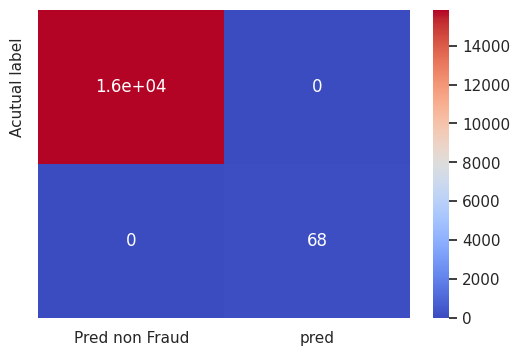

In [65]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_train,y_train_pred),
    annot=True,
    cmap="coolwarm",
    xticklabels=["Pred non Fraud",'pred'],
    yticklabels=["Acutual label"],
)
plt.show()


In [62]:
y_test_pred=rf_pipeline.predict(X_test)
test_acc=accuracy_score(y_test,y_test_pred)*100
print("Accuracy Score:",test_acc)

Accuracy Score: 99.79899497487436


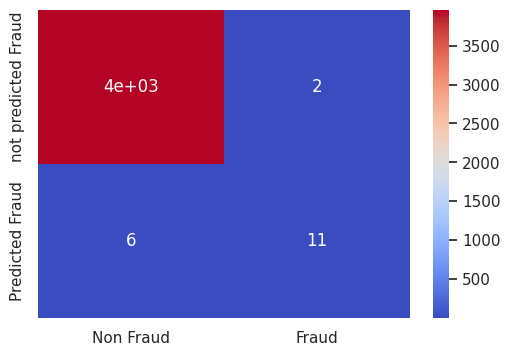

In [68]:
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test,y_test_pred),
    annot=True,
    cmap="coolwarm",
    xticklabels=["Non Fraud","Fraud"],
    yticklabels=[ "not predicted Fraud","Predicted Fraud"],
)
plt.show()


In [70]:
print("classification report",classification_report(y_test_pred,y_test))

classification report               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3967
         1.0       0.65      0.85      0.73        13

    accuracy                           1.00      3980
   macro avg       0.82      0.92      0.87      3980
weighted avg       1.00      1.00      1.00      3980



In [71]:
test_prob=rf_pipeline.predict_proba(X_test)[:,1]
print("Test Average precison Score:",average_precision_score(y_test,test_prob))

Test Average precison Score: 0.8284520347213846


Building a predicted system

In [125]:
def fraud_detection(input_features):
  # input_features=np.array(input_features).reshape(1,-1)
  new_input=pd.DataFrame([input_features],columns=X_train.columns)
  class_predicted=rf_pipeline.predict(new_input)
  if class_predicted==1:
    print("Fraud Transcation Detected❌")
  else:
    print("Regular Transcation ✅:")


In [116]:
y_test[y_test==0].head().index

Index([263020, 11378, 147283, 219439, 36939], dtype='int64')

In [117]:
y_test[y_test==1].head().index


Index([77348, 102442, 119781, 48094, 42958], dtype='int64')

In [126]:
# 8354
# print(X_test.columns)
test=X_test.iloc[8354]
fraud_detection(test)

Regular Transcation ✅:


In [92]:
y_test.head().index

Index([13745, 4265, 10183, 4859, 9917], dtype='int64')